In [ ]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd

sp500 = yf.download("^GSPC", start="2023-01-01", end="2025-01-01")
sp500 = sp500[["Close"]]
sp500.columns = ["SP500_Close"]

print(sp500.head(10))
print(f"\nTotal rows: {len(sp500)}")

/tmp/ipykernel_11022/158011333.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2023-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

            SP500_Close
Date                   
2023-01-03  3824.139893
2023-01-04  3852.969971
2023-01-05  3808.100098
2023-01-06  3895.080078
2023-01-09  3892.090088
2023-01-10  3919.250000
2023-01-11  3969.610107
2023-01-12  3983.169922
2023-01-13  3999.090088
2023-01-17  3990.969971

Total rows: 502


In [ ]:
!pip install pandas-datareader -q

In [ ]:
import pandas_datareader as pdr
import datetime

# Pull 10-year Treasury yield from FRED
start = datetime.datetime(2023, 1, 1)
end = datetime.datetime(2025, 1, 1)

treasury = pdr.get_data_fred('GS10', start, end)
treasury.columns = ["Treasury_10Y_Yield"]

print(treasury.head(10))
print(f"\nTotal rows: {len(treasury)}")

            Treasury_10Y_Yield
DATE                          
2023-01-01                3.53
2023-02-01                3.75
2023-03-01                3.66
2023-04-01                3.46
2023-05-01                3.57
2023-06-01                3.75
2023-07-01                3.90
2023-08-01                4.17
2023-09-01                4.38
2023-10-01                4.80

Total rows: 25


In [ ]:
import requests

# Pull DeFi protocol yields from DeFiLlama (free public API)
url = "https://yields.llama.fi/pools"
response = requests.get(url)
data = response.json()

# Convert to DataFrame
import pandas as pd
defi = pd.DataFrame(data["data"])

# Filter for the biggest, most established protocols only
defi_filtered = defi[
    (defi["tvlUsd"] > 500_000_000) &  # over $500M locked
    (defi["apy"] > 0) &               # positive yield
    (defi["apy"] < 100)               # remove outliers
][["project", "symbol", "tvlUsd", "apy"]].drop_duplicates(subset="project")

defi_filtered = defi_filtered.sort_values("apy", ascending=False).head(15)
defi_filtered.columns = ["Protocol", "Asset", "TVL_USD", "APY_%"]

print(defi_filtered.to_string(index=False))

             Protocol   Asset    TVL_USD   APY_%
  jito-liquid-staking JITOSOL 1151452931 5.86000
   binance-staked-sol   BNSOL  986015870 5.35391
doublezero-staked-sol   DZSOL  935421647 5.17096
 lista-liquid-staking SLISBNB  621870957 4.50100
                maple    USDC 3186312913 4.18725
            sparklend    USDS  614220663 3.91860
          sky-lending   SUSDS 6566787752 3.75000
    ondo-yield-assets    USDY  586832548 3.55000
          ethena-usde   SUSDE 3567088130 3.53512
        spark-savings    USDT  657474445 3.48000
         jupiter-lend    USDC  518799487 3.43228
       ether.fi-stake   WEETH 5964397938 2.81915
           usual-usd0   BUSD0  503682593 2.65806
                 kelp   RSETH 1249504963 2.55000
    liquid-collective   LSETH  599166126 2.54771


In [ ]:
# Combine S&P 500, Treasury, and DeFi into a summary comparison table
summary = pd.DataFrame({
    "Asset Class": ["S&P 500 (Equities)", "US 10Y Treasury (Bonds)",
                    "DeFi - Jito (Top Yield)", "DeFi - Spark Savings",
                    "DeFi - Average (Top 15)"],
    "Type": ["Traditional", "Traditional", "DeFi", "DeFi", "DeFi"],
    "Current_Yield_or_Return_%": [
        round(((sp500["SP500_Close"].iloc[-1] / sp500["SP500_Close"].iloc[0]) - 1) * 100, 2),
        round(treasury["Treasury_10Y_Yield"].iloc[-1], 2),
        round(defi_filtered["APY_%"].iloc[0], 2),
        round(defi_filtered[defi_filtered["Protocol"] == "spark-savings"]["APY_%"].values[0], 2),
        round(defi_filtered["APY_%"].mean(), 2)
    ]
})

print(summary.to_string(index=False))

# Save to CSV
summary.to_csv("comparison_summary.csv", index=False)
print("\nSaved to comparison_summary.csv")

            Asset Class        Type  Current_Yield_or_Return_%
     S&P 500 (Equities) Traditional                      53.80
US 10Y Treasury (Bonds) Traditional                       4.63
DeFi - Jito (Top Yield)        DeFi                       5.86
   DeFi - Spark Savings        DeFi                       3.48
DeFi - Average (Top 15)        DeFi                       3.82

Saved to comparison_summary.csv


In [ ]:
import numpy as np

# Calculate S&P 500 daily returns
sp500["Daily_Return"] = sp500["SP500_Close"].pct_change()

# Annualized volatility (std of daily returns * sqrt of 252 trading days)
sp500_volatility = sp500["Daily_Return"].std() * np.sqrt(252) * 100

# Annualized return
sp500_annual_return = ((sp500["SP500_Close"].iloc[-1] / sp500["SP500_Close"].iloc[0]) - 1) * 100 / 2

# Sharpe Ratio = (Return - Risk Free Rate) / Volatility
risk_free = treasury["Treasury_10Y_Yield"].mean()
sp500_sharpe = (sp500_annual_return - risk_free) / sp500_volatility

print(f"S&P 500 Annualized Return:    {sp500_annual_return:.2f}%")
print(f"S&P 500 Annualized Volatility: {sp500_volatility:.2f}%")
print(f"S&P 500 Sharpe Ratio:          {sp500_sharpe:.3f}")
print(f"\nRisk-Free Rate Used:           {risk_free:.2f}%")

S&P 500 Annualized Return:    26.90%
S&P 500 Annualized Volatility: 12.87%
S&P 500 Sharpe Ratio:          1.772

Risk-Free Rate Used:           4.10%


In [ ]:
# DeFi doesn't have daily price data the same way, so we compare differently
# We'll estimate DeFi Sharpe using yield as return and assume volatility from research

defi_top_yield = defi_filtered["APY_%"].iloc[0]
defi_avg_yield = defi_filtered["APY_%"].mean()

# DeFi protocols have significantly higher volatility than treasuries
# Conservative estimate: ~15% annualized volatility for established protocols
defi_volatility_est = 15.0

defi_top_sharpe = (defi_top_yield - risk_free) / defi_volatility_est
defi_avg_sharpe = (defi_avg_yield - risk_free) / defi_volatility_est
treasury_sharpe = (treasury["Treasury_10Y_Yield"].iloc[-1] - risk_free) / 0.5

print("=" * 50)
print("RISK-RETURN COMPARISON SUMMARY")
print("=" * 50)
print(f"\nS&P 500")
print(f"  Return:     {sp500_annual_return:.2f}%")
print(f"  Volatility: {sp500_volatility:.2f}%")
print(f"  Sharpe:     {sp500_sharpe:.3f}")
print(f"\nUS 10Y Treasury")
print(f"  Yield:      {treasury['Treasury_10Y_Yield'].iloc[-1]:.2f}%")
print(f"  Sharpe:     {treasury_sharpe:.3f}")
print(f"\nDeFi - Top Protocol (Jito)")
print(f"  Yield:      {defi_top_yield:.2f}%")
print(f"  Est. Sharpe:{defi_top_sharpe:.3f}")
print(f"\nDeFi - Average (Top 15)")
print(f"  Yield:      {defi_avg_yield:.2f}%")
print(f"  Est. Sharpe:{defi_avg_sharpe:.3f}")

RISK-RETURN COMPARISON SUMMARY

S&P 500
  Return:     26.90%
  Volatility: 12.87%
  Sharpe:     1.772

US 10Y Treasury
  Yield:      4.63%
  Sharpe:     1.050

DeFi - Top Protocol (Jito)
  Yield:      5.86%
  Est. Sharpe:0.117

DeFi - Average (Top 15)
  Yield:      3.82%
  Est. Sharpe:-0.019


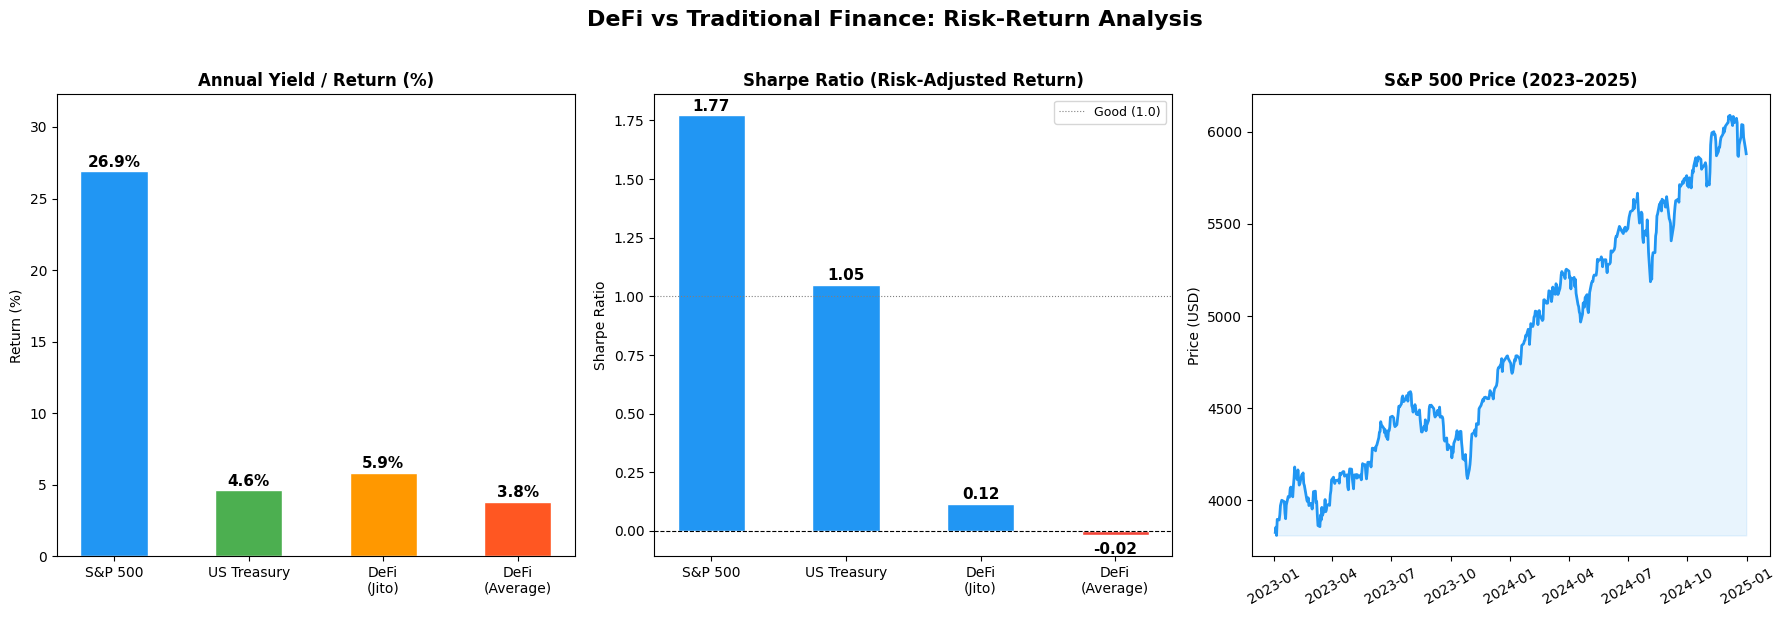

Chart saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("DeFi vs Traditional Finance: Risk-Return Analysis",
             fontsize=16, fontweight='bold', y=1.02)

# ── Chart 1: Yield/Return Comparison ──
assets = ["S&P 500", "US Treasury", "DeFi\n(Jito)", "DeFi\n(Average)"]
returns = [sp500_annual_return, treasury["Treasury_10Y_Yield"].iloc[-1],
           defi_top_yield, defi_avg_yield]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#FF5722"]

bars = axes[0].bar(assets, returns, color=colors, width=0.5, edgecolor="white")
axes[0].set_title("Annual Yield / Return (%)", fontweight="bold")
axes[0].set_ylabel("Return (%)")
for bar, val in zip(bars, returns):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontweight="bold", fontsize=11)
axes[0].set_ylim(0, max(returns) * 1.2)

# ── Chart 2: Sharpe Ratio Comparison ──
sharpes = [sp500_sharpe, treasury_sharpe, defi_top_sharpe, defi_avg_sharpe]
sharpe_colors = ["#2196F3" if s > 0 else "#F44336" for s in sharpes]

bars2 = axes[1].bar(assets, sharpes, color=sharpe_colors, width=0.5, edgecolor="white")
axes[1].set_title("Sharpe Ratio (Risk-Adjusted Return)", fontweight="bold")
axes[1].set_ylabel("Sharpe Ratio")
axes[1].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
axes[1].axhline(y=1, color="gray", linewidth=0.8, linestyle=":", label="Good (1.0)")
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, sharpes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.08,
                 f"{val:.2f}", ha="center", fontweight="bold", fontsize=11)

# ── Chart 3: S&P 500 Price Over Time ──
axes[2].plot(sp500.index, sp500["SP500_Close"], color="#2196F3", linewidth=2)
axes[2].fill_between(sp500.index, sp500["SP500_Close"],
                     sp500["SP500_Close"].min(), alpha=0.1, color="#2196F3")
axes[2].set_title("S&P 500 Price (2023–2025)", fontweight="bold")
axes[2].set_ylabel("Price (USD)")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("defi_vs_traditional.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved!")

In [ ]:
from google.colab import files
files.download("defi_vs_traditional.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>